In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices("GPU")) > 0)
print('All imports done.')

TensorFlow version: 2.20.0
GPU available: False
All imports done.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


CSV_PATH = '/content/drive/MyDrive/Activity_demo/classifier_ready.csv'


print('Loading dataset...')
df = pd.read_csv(CSV_PATH)

# Drop the non-encoded activity column — we use activity_label only
df = df.drop(columns=['activity'])

print(f'Shape: {df.shape}')
print(f'Null values: {df.isnull().sum().sum()}')
print(f'\nClass distribution before dropping elevator:')
print(df['activity_label'].value_counts().sort_index())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading dataset...
Shape: (1137279, 41)
Null values: 0

Class distribution before dropping elevator:
activity_label
0     68762
1    119819
2    135127
3     65917
4     82574
5     18119
6    222345
7     20506
8     89144
9    314966
Name: count, dtype: int64


In [13]:
# Drop both elevator classes — they are not gait activities
# and they heavily confuse the model with 'standing'
ELEVATOR_LABELS = [0, 8]  # 0=down_by_elevator, 8=up_by_elevator

df = df[~df['activity_label'].isin(ELEVATOR_LABELS)].copy().reset_index(drop=True)

# Remap remaining labels to 0-7 (no gaps)
# Original: 1,2,3,4,5,6,7,9
# New:      0,1,2,3,4,5,6,7
label_remap = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 9: 7}
df['activity_label'] = df['activity_label'].map(label_remap)

print(f'Shape after dropping elevator classes: {df.shape}')
print(f'\nNew class distribution:')
print(df['activity_label'].value_counts().sort_index())
print(f'\nLabel mapping: {label_remap}')

Shape after dropping elevator classes: (979373, 41)

New class distribution:
activity_label
0    119819
1    135127
2     65917
3     82574
4     18119
5    222345
6     20506
7    314966
Name: count, dtype: int64

Label mapping: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 9: 7}


In [14]:
# Split by subject — no person appears in two sets
# Subjects 1-14  -> Training
# Subjects 15-16 -> Validation
# Subjects 17-18 -> Test

train_df = df[df['subject_id'] <= 14].copy().reset_index(drop=True)
val_df   = df[(df['subject_id'] == 15) | (df['subject_id'] == 16)].copy().reset_index(drop=True)
test_df  = df[df['subject_id'] >= 17].copy().reset_index(drop=True)

DROP_COLS = ['subject_id', 'trial_id', 'activity_label']

X_train = train_df.drop(columns=DROP_COLS)
y_train = train_df['activity_label']

X_val   = val_df.drop(columns=DROP_COLS)
y_val   = val_df['activity_label']

X_test  = test_df.drop(columns=DROP_COLS)
y_test  = test_df['activity_label']

print(f'Train rows : {len(X_train):,}  (subjects 1-14)')
print(f'Val rows   : {len(X_val):,}  (subjects 15-16)')
print(f'Test rows  : {len(X_test):,}  (subjects 17-18)')
print(f'Feature count: {X_train.shape[1]}')

Train rows : 777,468  (subjects 1-14)
Val rows   : 94,943  (subjects 15-16)
Test rows  : 106,962  (subjects 17-18)
Feature count: 38


In [15]:
# Fit ONLY on training data — then apply same scale to val and test
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print('Scaling done.')
print(f'Train mean (should be ~0): {X_train_scaled.mean():.4f}')
print(f'Train std  (should be ~1): {X_train_scaled.std():.4f}')

Scaling done.
Train mean (should be ~0): -0.0000
Train std  (should be ~1): 1.0000


In [16]:
# 8 classes now — elevator classes removed
ACTIVITY_NAMES = [
    'going_down', 'going_up', 'running', 'sitting',
    'sitting_down', 'standing', 'standing_up', 'walking'
]
NUM_CLASSES = len(ACTIVITY_NAMES)

# Computed from training set only
classes = np.array(sorted(y_train.unique()))
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(enumerate(weights))

print('Class weights (higher = rarer class = penalized more if wrong):')
for label, weight in class_weight_dict.items():
    print(f'  {label} ({ACTIVITY_NAMES[label]}): {weight:.3f}')

Class weights (higher = rarer class = penalized more if wrong):
  0 (going_down): 1.088
  1 (going_up): 0.981
  2 (running): 1.677
  3 (sitting): 1.684
  4 (sitting_down): 7.044
  5 (standing): 0.543
  6 (standing_up): 5.946
  7 (walking): 0.368


In [17]:
WINDOW_SIZE = 50   # 50 timesteps = 0.5 seconds at 100Hz
STEP_SIZE   = 25   # 50% overlap between windows

def create_sequences_safe(df_split, X_scaled, window_size=WINDOW_SIZE, step=STEP_SIZE):
    """
    Creates sliding windows WITHIN each subject-trial group only.
    Prevents any window from mixing two different people's recordings.
    """
    X_seq, y_seq = [], []

    start_idx = 0
    for (subj, trial), group in df_split.groupby(['subject_id', 'trial_id']):
        end_idx = start_idx + len(group)

        X_group = X_scaled[start_idx:end_idx]
        y_group = df_split['activity_label'].values[start_idx:end_idx]

        # Slide window only within this one recording
        for i in range(0, len(X_group) - window_size, step):
            X_seq.append(X_group[i : i + window_size])
            y_seq.append(y_group[i + window_size - 1])  # label = last row of window

        start_idx = end_idx

    return np.array(X_seq, dtype=np.float32), np.array(y_seq)


print('Creating sequences — windows will never cross subject/trial boundaries...')

X_train_seq, y_train_seq = create_sequences_safe(train_df, X_train_scaled)
X_val_seq,   y_val_seq   = create_sequences_safe(val_df,   X_val_scaled)
X_test_seq,  y_test_seq  = create_sequences_safe(test_df,  X_test_scaled)

print(f'Train sequences shape : {X_train_seq.shape}')  # (samples, 50, 38)
print(f'Val sequences shape   : {X_val_seq.shape}')
print(f'Test sequences shape  : {X_test_seq.shape}')

# One-hot encode labels for Keras
y_train_cat = to_categorical(y_train_seq, num_classes=NUM_CLASSES)
y_val_cat   = to_categorical(y_val_seq,   num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test_seq,  num_classes=NUM_CLASSES)

print('Sequences ready.')

Creating sequences — windows will never cross subject/trial boundaries...
Train sequences shape : (30650, 50, 38)
Val sequences shape   : (3750, 50, 38)
Test sequences shape  : (4218, 50, 38)
Sequences ready.


In [18]:
NUM_FEATURES = X_train_seq.shape[2]

tf.random.set_seed(42)

lstm_model = Sequential([
    # First LSTM layer — return_sequences=True feeds into second LSTM
    LSTM(128, input_shape=(WINDOW_SIZE, NUM_FEATURES), return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),

    # Second LSTM layer — outputs one vector per window
    LSTM(64, return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),

    # Dense layer
    Dense(64, activation='relu'),
    Dropout(0.2),

    # Output — one probability per activity class
    Dense(NUM_CLASSES, activation='softmax')
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50, 128)        │        85,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,360 (548.28 KB)

 Trainable params: 139,976 (546.78 KB)

 Non-trainable params: 384 (1.50 KB)

In [19]:
callbacks = [
    # Stop if val_loss doesn't improve for 5 epochs, restore best weights
    EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1
    ),
    # Halve learning rate if stuck for 3 epochs
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    )
]

print('Training LSTM...')
print('Make sure GPU is on: Runtime -> Change runtime type -> T4 GPU')

history = lstm_model.fit(
    X_train_seq, y_train_cat,
    validation_data=(X_val_seq, y_val_cat),
    epochs=30,
    batch_size=512,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)
print('Training complete.')

Training LSTM...
Make sure GPU is on: Runtime -> Change runtime type -> T4 GPU
Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 67s 933ms/step - accuracy: 0.7265 - loss: 0.8278 - val_accuracy: 0.8387 - val_loss: 0.9223 - learning_rate: 0.0010
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 50s 836ms/step - accuracy: 0.9223 - loss: 0.3023 - val_accuracy: 0.8880 - val_loss: 0.4469 - learning_rate: 0.0010
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 83s 856ms/step - accuracy: 0.9368 - loss: 0.2428 - val_accuracy: 0.9299 - val_loss: 0.3364 - learning_rate: 0.0010
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 52s 866ms/step - accuracy: 0.9409 - loss: 0.2128 - val_accuracy: 0.9395 - val_loss: 0.2333 - learning_rate: 0.0010
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 80s 840ms/step - accuracy: 0.9460 - loss: 0.1852 - val_accuracy: 0.9347 - val_loss: 0.2467 - learning_rate: 0.0010
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 52s 876ms/step - accuracy: 0.9495 - loss: 0.1636 - val_accuracy: 0.9384 - val_loss: 0.2245 - learning_rate: 0.0010
Epo

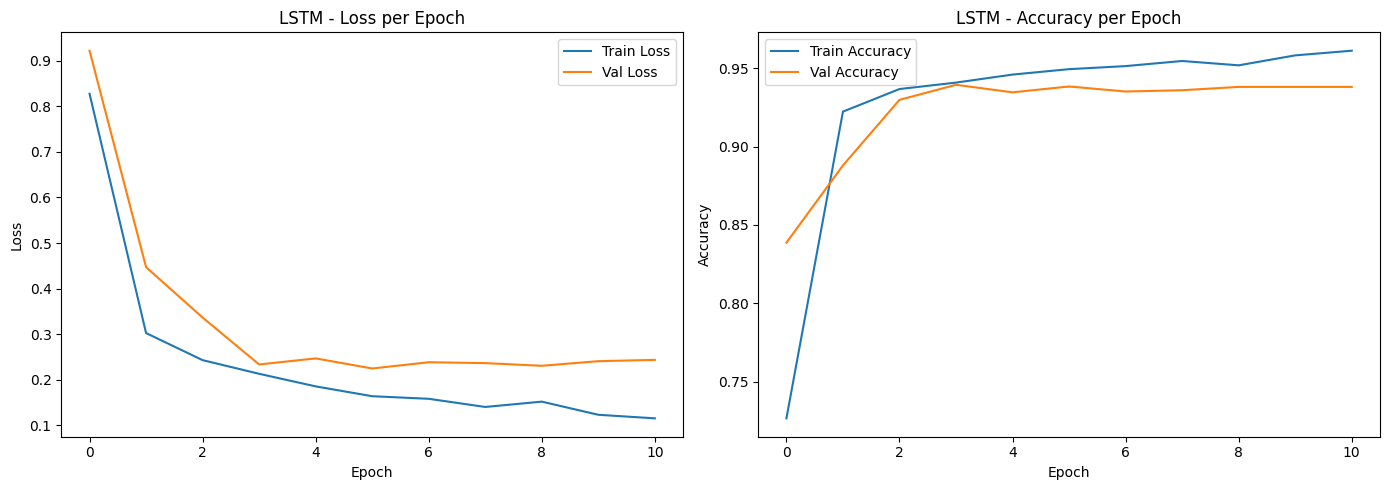

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM - Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('LSTM - Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150)
plt.show()


-------------------------------------------------------
LSTM - Validation Set
-------------------------------------------------------
Accuracy (weighted) : 0.9384
F1 Score (weighted) : 0.9394

Per-class breakdown:
              precision    recall  f1-score   support

  going_down       0.94      0.96      0.95       664
    going_up       0.91      0.98      0.94       718
     running       0.99      0.92      0.96        93
     sitting       0.99      0.96      0.98       416
sitting_down       0.78      0.92      0.85        78
    standing       0.99      0.93      0.96       780
 standing_up       0.64      0.96      0.77        76
     walking       0.95      0.88      0.92       925

    accuracy                           0.94      3750
   macro avg       0.90      0.94      0.91      3750
weighted avg       0.94      0.94      0.94      3750



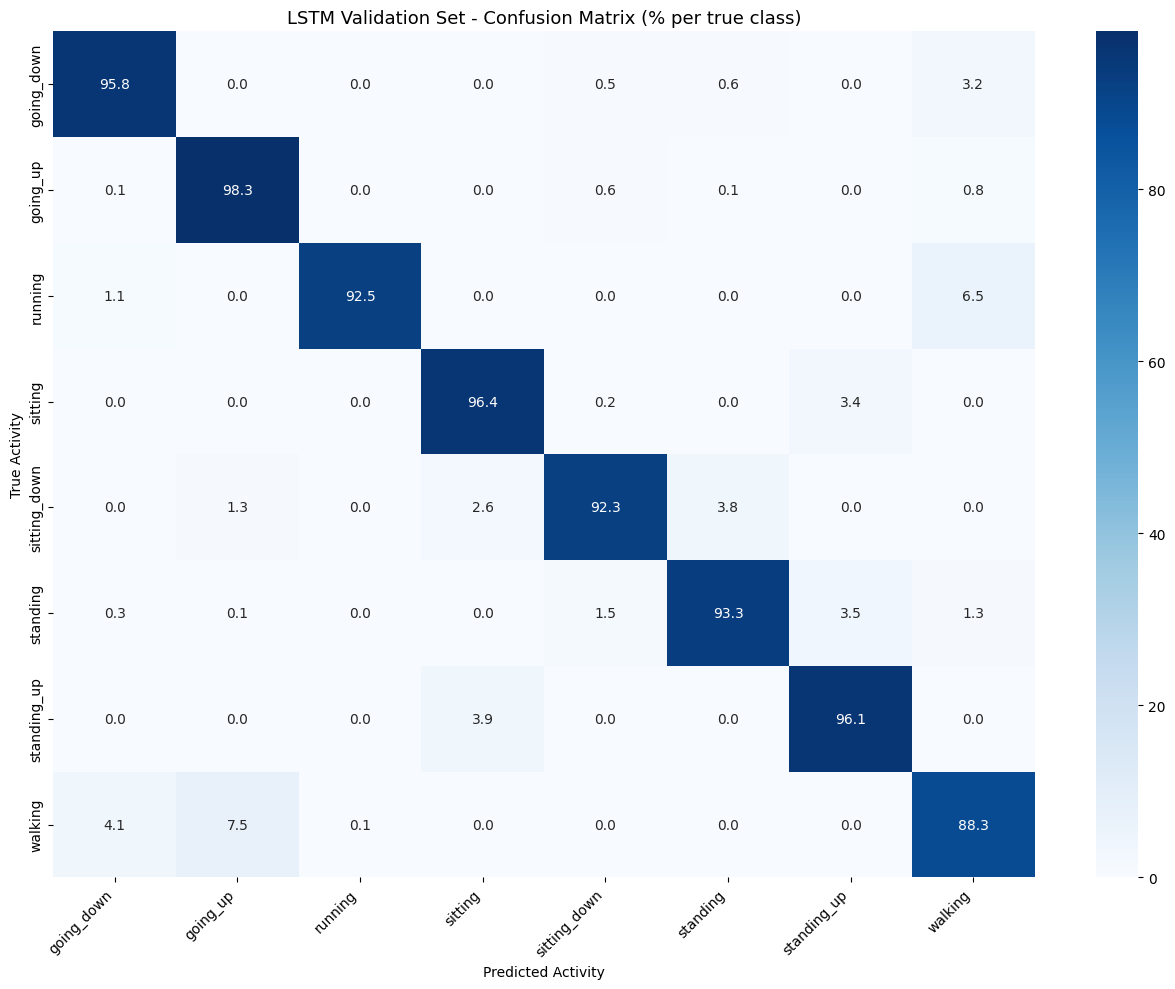


-------------------------------------------------------
LSTM - Test Set
-------------------------------------------------------
Accuracy (weighted) : 0.9393
F1 Score (weighted) : 0.9415

Per-class breakdown:
              precision    recall  f1-score   support

  going_down       0.94      0.97      0.95       554
    going_up       0.92      0.97      0.95       721
     running       0.94      0.98      0.96       226
     sitting       0.99      0.93      0.96       550
sitting_down       0.81      0.95      0.87       101
    standing       0.99      0.92      0.95       885
 standing_up       0.55      0.99      0.70        89
     walking       0.96      0.91      0.93      1092

    accuracy                           0.94      4218
   macro avg       0.89      0.95      0.91      4218
weighted avg       0.95      0.94      0.94      4218



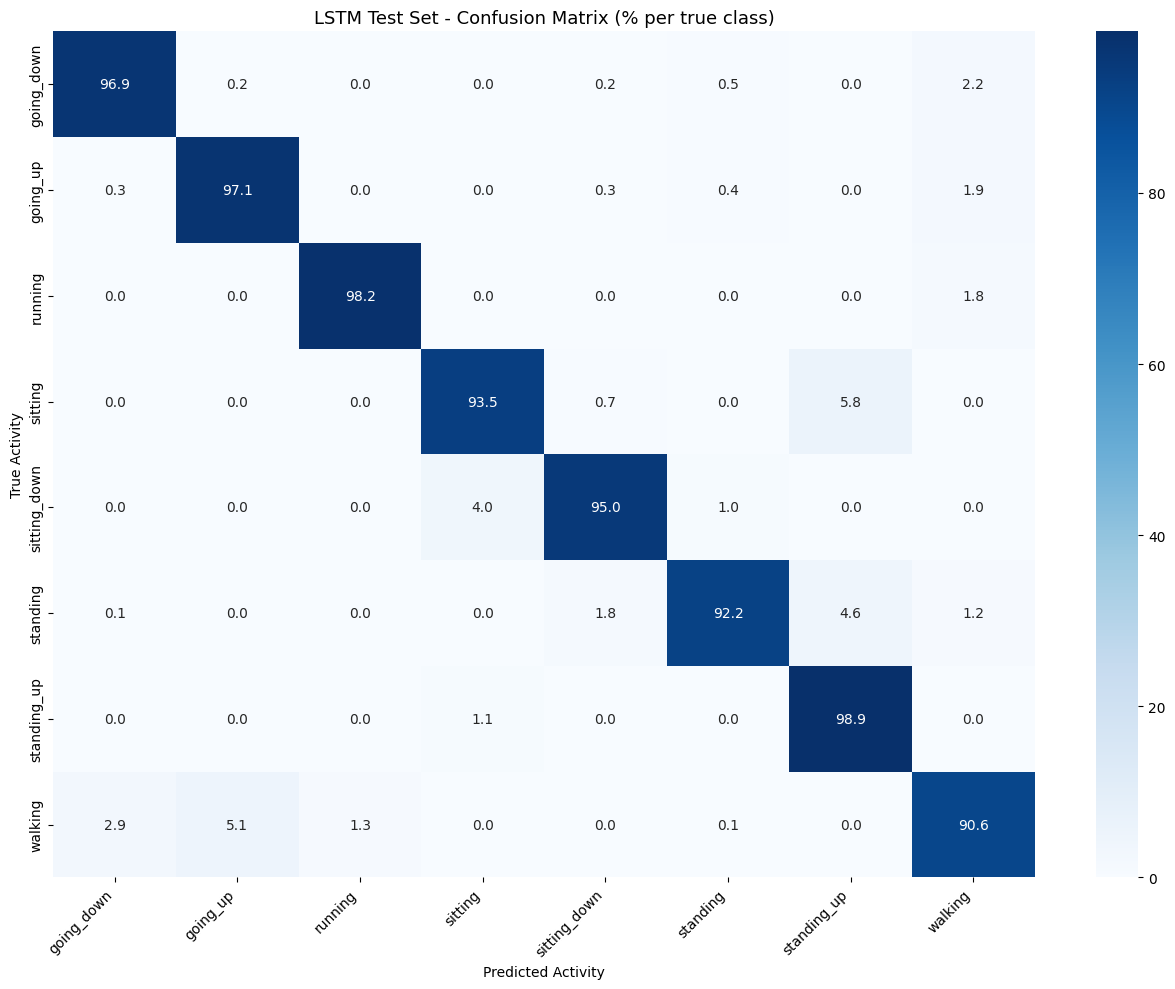


FINAL RESULTS SUMMARY
Val  Accuracy: 0.9384  |  Val  F1: 0.9394
Test Accuracy: 0.9393  |  Test F1: 0.9415


In [21]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    plt.figure(figsize=(13, 10))
    sns.heatmap(
        cm_pct,
        annot=True, fmt='.1f', cmap='Blues',
        xticklabels=ACTIVITY_NAMES,
        yticklabels=ACTIVITY_NAMES
    )
    plt.title(f'{title} - Confusion Matrix (% per true class)', fontsize=13)
    plt.ylabel('True Activity')
    plt.xlabel('Predicted Activity')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}_confusion_matrix.png', dpi=150)
    plt.show()


def evaluate(X_seq, y_seq, split_name):
    proba = lstm_model.predict(X_seq, batch_size=512, verbose=0)
    preds = np.argmax(proba, axis=1)

    acc = accuracy_score(y_seq, preds)
    f1  = f1_score(y_seq, preds, average='weighted')

    print(f'\n{"-"*55}')
    print(f'LSTM - {split_name}')
    print(f'{"-"*55}')
    print(f'Accuracy (weighted) : {acc:.4f}')
    print(f'F1 Score (weighted) : {f1:.4f}')
    print(f'\nPer-class breakdown:')
    print(classification_report(y_seq, preds, target_names=ACTIVITY_NAMES))
    plot_confusion_matrix(y_seq, preds, f'LSTM {split_name}')
    return acc, f1


val_acc,  val_f1  = evaluate(X_val_seq,  y_val_seq,  'Validation Set')
test_acc, test_f1 = evaluate(X_test_seq, y_test_seq, 'Test Set')

print(f'\n{"="*55}')
print('FINAL RESULTS SUMMARY')
print(f'{"="*55}')
print(f'Val  Accuracy: {val_acc:.4f}  |  Val  F1: {val_f1:.4f}')
print(f'Test Accuracy: {test_acc:.4f}  |  Test F1: {test_f1:.4f}')